# LECURA DE ARCHIVO DE DEFUNCIONES CONSOLIDADA

## 1. LIBRERIAS Y CONSTANTES

In [1]:
import os, gc, warnings
import numpy  as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", palette="muted")

# ── Rutas ──────────────────────────────────────────────────────────────────────
RUTA_PARQUET = (
    "/kaggle/input/datasets/nicolasacostaa/defunciones-consolidadas"
    "/defunciones_consolidadas.parquet"
)
COL_OBJETIVO = "Número de Fallecidos"

# ── Diccionario de etiquetas legibles por campo ────────────────────────────────
# Permite mostrar nombres descriptivos en los gráficos sin alterar los datos.
ETIQUETAS = {
    "CÓDIGO DEPARTAMENTO"          : "Departamento ocurrencia",
    "CÓDIGO MUNICIPIO"             : "Municipio ocurrencia",
    "ÁREA DEFUNCIÓN"               : "Área defunción",
    "AÑO"                          : "Año",
    "MES"                          : "Mes",
    "SEXO"                         : "Sexo",
    "AGRUPACIÓN EDADES 1"          : "Grupo de edad",
    "ESTADO CIVIL"                 : "Estado civil",
    "CÓDIGO DEPARTAMENTO RESIDENCIA": "Departamento residencia",
    "CÓDIGO MUNICIPIO RESIDENCIA"  : "Municipio residencia",
    "CÓDIGO SITIO DEFUNCIÓN"       : "Sitio de defunción",
    "CÓDIGO CAUSA BÁSICA DEFUNCIÓN": "Causa básica (CIE)",
    "CÓDIGO CERTIFICACIÓN MÉDICA"  : "Tipo certificación médica",
    "CÓDIGO CAUSA BÁSICA LISTA 105": "Causa básica lista 105",
}

# ── Decodificadores de códigos → etiquetas ────────────────────────────────────
DECODIFICADORES = {
    "SEXO"           : {"1": "Hombre", "2": "Mujer", "3": "Indeterminado"},
    "ÁREA DEFUNCIÓN" : {"1": "Cabecera", "2": "Centro poblado",
                        "3": "Rural disperso", "9": "Sin info"},
    "ESTADO CIVIL"   : {"1": "Soltero/a", "2": "Casado/a", "3": "Viudo/a",
                        "4": "Separado/a", "5": "Unión libre",
                        "6": "No aplica (< 10 años)", "9": "Sin info", "": "Sin info"},
    "CÓDIGO SITIO DEFUNCIÓN": {
        "1": "Hospital/clínica", "2": "Casa", "3": "Vía pública",
        "4": "Centro de salud", "5": "Bienestar", "6": "Otro", "9": "Sin info"},
    "CÓDIGO CERTIFICACIÓN MÉDICA": {
        "1": "Médico tratante", "2": "Médico no tratante",
        "3": "Médico legista",  "4": "Otro médico",
        "5": "Sin asistencia",  "9": "Sin info"},
}

print("Librerías y constantes cargadas ✓")
print(f"  Variable objetivo : {COL_OBJETIVO}")
print(f"  Variables de análisis: {len(ETIQUETAS)}")

Librerías y constantes cargadas ✓
  Variable objetivo : Número de Fallecidos
  Variables de análisis: 14


## 2. VERIFICACIÓN DE MEMORIA DISPONIBLE

In [4]:
def verificar_carga_ram(ruta_parquet: str, factor_seguridad: float = 1.5) -> dict:
    """
    Estima si hay RAM suficiente para cargar el Parquet y devuelve un diagnóstico.

    Parámetros
    ----------
    ruta_parquet     : str    Ruta al archivo Parquet.
    factor_seguridad : float  Multiplicador sobre el tamaño del archivo para
                              estimar la RAM que usará pandas (default 1.5×).
                              Con tipos category el uso real baja ~60-70 %.

    Retorna
    -------
    dict con las llaves:
        - tam_archivo_mb  : float   Tamaño del archivo en MB.
        - ram_estimada_mb : float   RAM estimada con pandas strings puros.
        - ram_optim_mb    : float   RAM estimada usando tipos category.
        - ram_libre_mb    : float   RAM libre actual en el sistema.
        - filas           : int     Número de filas según metadatos.
        - columnas        : int     Número de columnas.
        - puede_cargar    : bool    True si ram_optim_mb < ram_libre_mb * 0.85.
        - mensaje         : str     Resumen legible.

    Ejemplo
    -------
    >>> diag = verificar_carga_ram(RUTA_PARQUET)
    >>> if diag['puede_cargar']:
    ...     df = cargar_datos(RUTA_PARQUET)
    """
    import psutil

    # Metadatos del Parquet (sin cargar datos)
    meta          = pq.read_metadata(ruta_parquet)
    tam_mb        = os.path.getsize(ruta_parquet) / 1_048_576
    filas         = meta.num_rows
    columnas      = meta.num_columns

    ram_estimada  = tam_mb * factor_seguridad          # strings puros
    ram_optim     = ram_estimada * 0.35                # con category (~65 % ahorro)
    ram_libre_mb  = psutil.virtual_memory().available / 1_048_576
    ram_total_mb  = psutil.virtual_memory().total      / 1_048_576
    puede_cargar  = ram_optim < ram_libre_mb * 0.85

    estado = "✅ PUEDE CARGARSE" if puede_cargar else "❌ RAM INSUFICIENTE"
    mensaje = f"""{estado}
              Archivo           : {tam_mb:>8.1f} MB
              Filas / Columnas  : {filas:,} / {columnas}
              RAM estimada      : {ram_estimada:>8.1f} MB  (strings puros)
              RAM optimizada    : {ram_optim:>8.1f} MB  (con category)
              RAM libre         : {ram_libre_mb:>8.1f} MB  de {ram_total_mb:.0f} MB total
            """

    return {
        "tam_archivo_mb" : tam_mb,
        "ram_estimada_mb": ram_estimada,
        "ram_optim_mb"   : ram_optim,
        "ram_libre_mb"   : ram_libre_mb,
        "filas"          : filas,
        "columnas"       : columnas,
        "puede_cargar"   : puede_cargar,
        "mensaje"        : mensaje,
    }


diagnostico = verificar_carga_ram(RUTA_PARQUET)
print(diagnostico["mensaje"])


✅ PUEDE CARGARSE
              Archivo           :     40.9 MB
              Filas / Columnas  : 8,701,084 / 15
              RAM estimada      :     61.3 MB  (strings puros)
              RAM optimizada    :     21.5 MB  (con category)
              RAM libre         :  30825.5 MB  de 32103 MB total
            


## 3. CARGA OPTIMIZADA DEL DATASET

In [5]:
def cargar_datos(
    ruta_parquet: str,
    columnas: list[str] | None = None,
    forzar: bool = False,
) -> pd.DataFrame:
    """
    Carga el Parquet de defunciones con tipos optimizados para minimizar RAM.

    Parámetros
    ----------
    ruta_parquet : str
        Ruta al archivo Parquet.
    columnas : list[str] | None
        Subconjunto de columnas a leer. None = todas. Útil cuando solo se
        necesitan algunas variables para un análisis puntual.
    forzar : bool
        Si True, carga aunque el diagnóstico indique RAM insuficiente.
        Default False (lanza error si no hay RAM).

    Retorna
    -------
    pd.DataFrame
        Dataset con columnas string convertidas a category y la columna
        objetivo como int32.

    Estrategia de optimización de RAM
    -----------------------------------
    - Todas las columnas string → dtype category.
      Ahorra ~65 % vs strings puros porque pandas almacena un solo diccionario
      de valores únicos y usa enteros pequeños para las referencias.
    - COL_OBJETIVO → int32 (en lugar del int64 por defecto).
    - gc.collect() al final para liberar cualquier objeto intermedio.
    """
    diag = verificar_carga_ram(ruta_parquet)
    if not diag["puede_cargar"] and not forzar:
        raise MemoryError(
            f"RAM insuficiente para cargar el dataset.\n{diag['mensaje']}\n"
            "Usa columnas=[...] para cargar solo las que necesitas, "
            "o forzar=True para intentar de todas formas."
        )

    print("Cargando dataset...")
    df = pd.read_parquet(ruta_parquet, columns=columnas, engine="pyarrow")

    # Convertir strings a category
    cols_str = df.select_dtypes(include="object").columns.tolist()
    for col in cols_str:
        df[col] = df[col].astype("category")

    # Asegurar int32 en la variable objetivo
    if COL_OBJETIVO in df.columns:
        df[COL_OBJETIVO] = df[COL_OBJETIVO].astype("int32")

    gc.collect()

    ram_real = df.memory_usage(deep=True).sum() / 1_048_576
    print(f"Dataset cargado ✓")
    print(f"  Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"  RAM real    : {ram_real:.1f} MB")
    return df


# ── Cargar (solo si el diagnóstico lo permite) ────────────────────────────────
if diagnostico["puede_cargar"]:
    df = cargar_datos(RUTA_PARQUET)
else:
    print("⚠️  RAM insuficiente. Cargando solo columnas esenciales...")
    cols_esenciales = [
        "AÑO", "MES", "SEXO", "ÁREA DEFUNCIÓN", "AGRUPACIÓN EDADES 1",
        "ESTADO CIVIL", "CÓDIGO DEPARTAMENTO", "CÓDIGO SITIO DEFUNCIÓN",
        "CÓDIGO CAUSA BÁSICA LISTA 105", COL_OBJETIVO,
    ]
    df = cargar_datos(RUTA_PARQUET, columnas=cols_esenciales)


Cargando dataset...
Dataset cargado ✓
  Dimensiones : 8,701,084 filas × 15 columnas
  RAM real    : 175.2 MB


## 4. RESUMEN GENERAL DEL DATASET

In [8]:
def resumen_general(df: pd.DataFrame, col_objetivo: str = COL_OBJETIVO) -> pd.DataFrame:
    """
    Genera una tabla de resumen con metadatos de cada columna.

    Parámetros
    ----------
    df           : pd.DataFrame   Dataset cargado.
    col_objetivo : str            Nombre de la variable objetivo.

    Retorna
    -------
    pd.DataFrame con columnas:
        Campo, Etiqueta, Tipo, Valores únicos, Nulos (%),
        Fallecidos cubiertos, Cobertura (%), Rol.
    """

    import pandas as pd

    # Validación básica
    if col_objetivo not in df.columns:
        raise ValueError(f"La columna objetivo '{col_objetivo}' no existe en el DataFrame.")

    total_fall = df[col_objetivo].sum()
    filas = []

    for col in df.columns:
        unicos  = df[col].nunique(dropna=True)
        nulos_p = df[col].isna().mean() * 100

        # Máscara de valores válidos
        mask_valido = df[col].notna()

        # Evitar problemas con category / strings vacíos
        if df[col].dtype.name in ["category", "object", "string"]:
            mask_valido &= (df[col].astype(str) != "")

        # Fallecidos cubiertos
        try:
            fall_cub = df.loc[mask_valido, col_objetivo].sum()
        except Exception:
            fall_cub = 0

        cob_p = (fall_cub / total_fall * 100) if total_fall else 0
        rol = "🎯 Objetivo" if col == col_objetivo else "📊 Predictora"

        filas.append({
            "Campo"                : col,
            "Etiqueta"             : ETIQUETAS.get(col, col) if 'ETIQUETAS' in globals() else col,
            "Tipo"                 : str(df[col].dtype),
            "Valores únicos"       : unicos,
            "Nulos (%)"            : round(nulos_p, 2),
            "Fallecidos cubiertos" : fall_cub,
            "Cobertura (%)"        : round(cob_p, 2),
            "Rol"                  : rol,
        })

    resumen = pd.DataFrame(filas)

    # 🔧 Manejo robusto del rango temporal
    rango = "No disponible"
    if 'AÑO' in df.columns:
        try:
            anio = pd.to_numeric(df['AÑO'], errors='coerce')
            if anio.notna().any():
                rango = f"{int(anio.min())} – {int(anio.max())}"
        except Exception:
            pass

    # Prints informativos
    print(f"Total de fallecidos en el dataset : {total_fall:,}")
    print(f"Rango temporal                    : {rango}")
    print(f"Dimensiones                       : {df.shape[0]:,} filas × {df.shape[1]} cols")
    print()

    return resumen


In [10]:
resumen = resumen_general(df) 
resumen

Total de fallecidos en el dataset : 8,825,031
Rango temporal                    : 1979 – 2024
Dimensiones                       : 8,701,084 filas × 15 cols



,Campo,Etiqueta,Tipo,Valores únicos,Nulos (%),Fallecidos cubiertos,Cobertura (%),Rol
0,CÓDIGO DEPARTAMENTO,Departamento ocurrencia,category,34,0.00,8825031,100.00,📊 Predictora
1,CÓDIGO MUNICIPIO,Municipio ocurrencia,category,592,0.00,8825031,100.00,📊 Predictora
2,ÁREA DEFUNCIÓN,Área defunción,category,4,0.00,8825031,100.00,📊 Predictora
3,AÑO,Año,category,46,0.00,8825031,100.00,📊 Predictora
4,MES,Mes,category,12,0.00,8825031,100.00,📊 Predictora
5,SEXO,Sexo,category,3,0.00,8825031,100.00,📊 Predictora
6,AGRUPACIÓN EDADES 1,Grupo de edad,category,30,0.00,8825031,100.00,📊 Predictora
7,ESTADO CIVIL,Estado civil,category,8,0.00,8825030,100.00,📊 Predictora
8,CÓDIGO DEPARTAMENTO RESIDENCIA,Departamento residencia,category,37,0.00,8783609,99.53,📊 Predictora
9,CÓDIGO MUNICIPIO RESIDENCIA,Municipio residencia,category,609,0.00,8780712,99.50,📊 Predictora


## 5. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

═══════════════════════════════════════════════════════
  ESTADÍSTICAS — Número de Fallecidos
═══════════════════════════════════════════════════════
  Grupos (filas)    : 8,701,084
  Total fallecidos  : 8,825,031
  Media por grupo   : 1.01
  Mediana           : 1
  Desv. estándar    : 0.25
  Mínimo            : 1
  Máximo            : 81
  Grupos con valor 1: 8,619,248 (99.1 %)

 Percentil (%)  Fallecidos
          1.00        1.00
          5.00        1.00
         10.00        1.00
         25.00        1.00
         50.00        1.00
         75.00        1.00
         90.00        1.00
         95.00        1.00
         99.00        1.00
         99.90        3.00


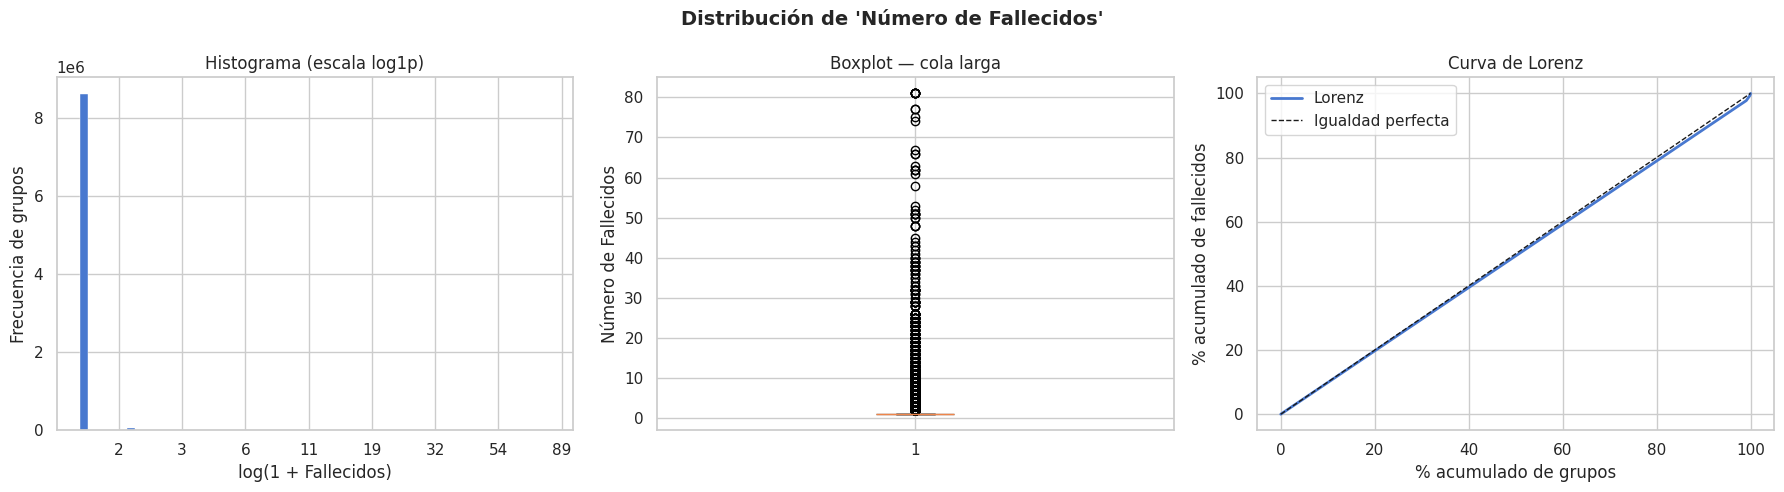

In [11]:
def estadisticas_objetivo(
    df: pd.DataFrame,
    col_objetivo: str = COL_OBJETIVO,
    top_n: int = 20,
) -> pd.DataFrame:
    """
    Calcula estadísticas descriptivas de la variable objetivo y genera
    visualizaciones de su distribución.

    Parámetros
    ----------
    df           : pd.DataFrame   Dataset cargado.
    col_objetivo : str            Nombre de la variable objetivo.
    top_n        : int            Cuántos percentiles extremos mostrar.

    Retorna
    -------
    pd.DataFrame con percentiles de la distribución (p1, p5, p10...p99).

    Gráficos generados
    -------------------
    1. Histograma + KDE de la distribución (escala log).
    2. Boxplot para visualizar cola larga y outliers.
    3. Curva de Lorenz — concentración: qué % de grupos acumula qué % de muertes.
    """
    serie = df[col_objetivo]

    # Tabla de percentiles
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]
    tabla = pd.DataFrame({
        "Percentil (%)": percentiles,
        "Fallecidos"   : [serie.quantile(p/100) for p in percentiles],
    })

    print("═" * 55)
    print(f"  ESTADÍSTICAS — {col_objetivo}")
    print("═" * 55)
    print(f"  Grupos (filas)    : {len(serie):,}")
    print(f"  Total fallecidos  : {serie.sum():,}")
    print(f"  Media por grupo   : {serie.mean():,.2f}")
    print(f"  Mediana           : {serie.median():,.0f}")
    print(f"  Desv. estándar    : {serie.std():,.2f}")
    print(f"  Mínimo            : {serie.min():,}")
    print(f"  Máximo            : {serie.max():,}")
    print(f"  Grupos con valor 1: {(serie == 1).sum():,} ({(serie==1).mean()*100:.1f} %)")
    print()
    print(tabla.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Distribución de '{col_objetivo}'", fontsize=14, fontweight="bold")

    # 1. Histograma log
    axes[0].hist(np.log1p(serie), bins=60, color="#4878CF", edgecolor="white", linewidth=0.3)
    axes[0].set_title("Histograma (escala log1p)")
    axes[0].set_xlabel("log(1 + Fallecidos)")
    axes[0].set_ylabel("Frecuencia de grupos")
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{np.expm1(x):.0f}")
    )

    # 2. Boxplot
    axes[1].boxplot(serie, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4878CF", alpha=0.6))
    axes[1].set_title("Boxplot — cola larga")
    axes[1].set_ylabel("Número de Fallecidos")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

    # 3. Curva de Lorenz
    s_sorted = np.sort(serie.values)
    cum_fall  = np.cumsum(s_sorted) / s_sorted.sum()
    cum_grup  = np.arange(1, len(s_sorted)+1) / len(s_sorted)
    axes[2].plot(cum_grup * 100, cum_fall * 100, color="#4878CF", linewidth=2, label="Lorenz")
    axes[2].plot([0, 100], [0, 100], "k--", linewidth=1, label="Igualdad perfecta")
    axes[2].set_title("Curva de Lorenz")
    axes[2].set_xlabel("% acumulado de grupos")
    axes[2].set_ylabel("% acumulado de fallecidos")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    return tabla


tabla_percentiles = estadisticas_objetivo(df)


## 6. DISTRIBUCIÓN DE FALLECIDOS POR VARIABLE


═══════════════════════════════════════════════════════
  SEXO  (3 categorías)
═══════════════════════════════════════════════════════
         Sexo  Fallecidos  % Total  Media/grupo
       Hombre     5085707    57.63         1.02
        Mujer     3738168    42.36         1.01
Indeterminado        1156     0.01         1.03


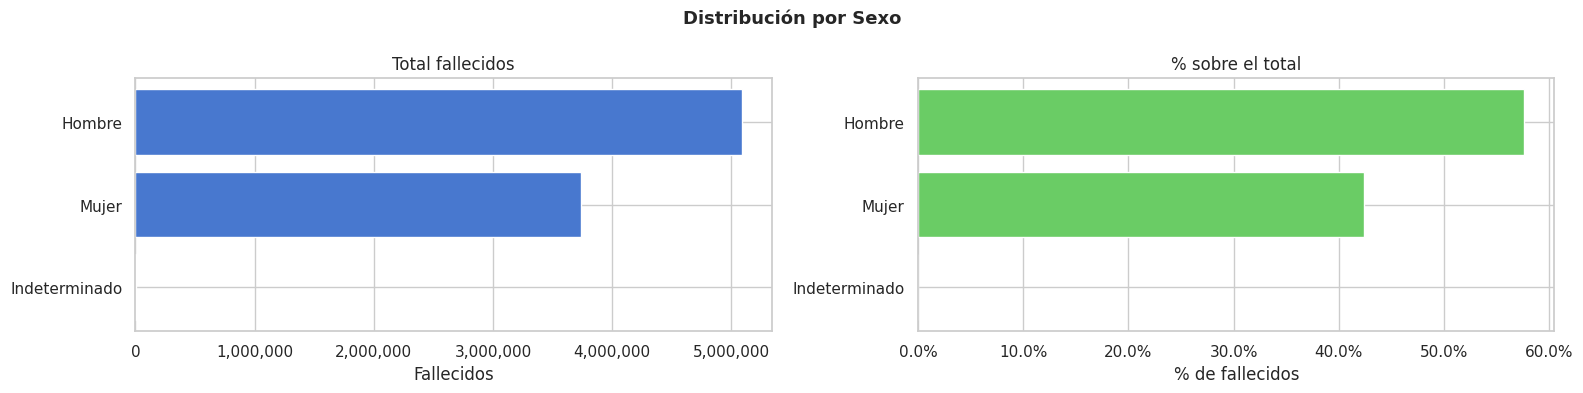

In [12]:
def distribucion_por_variable(
    df: pd.DataFrame,
    columna: str,
    col_objetivo: str = COL_OBJETIVO,
    top_n: int = 20,
    graficar: bool = True,
    ordenar_por: str = "fallecidos",
) -> pd.DataFrame:
    """
    Calcula la distribución de la variable objetivo agrupada por una columna.

    Parámetros
    ----------
    df           : pd.DataFrame   Dataset cargado.
    columna      : str            Variable por la que se agrupa.
    col_objetivo : str            Variable objetivo. Default: COL_OBJETIVO.
    top_n        : int            Máximo de categorías a mostrar en el gráfico.
    graficar     : bool           Si True, genera gráfico de barras horizontales.
    ordenar_por  : str            'fallecidos' o 'categoria'.

    Retorna
    -------
    pd.DataFrame con columnas:
        [columna], Fallecidos, Grupos, Fallecidos_pct, Fallecidos_acum_pct,
        Fallecidos_por_grupo (promedio).

    Ejemplo
    -------
    >>> distribucion_por_variable(df, 'SEXO')
    >>> distribucion_por_variable(df, 'AÑO', top_n=46)
    """
    etiqueta = ETIQUETAS.get(columna, columna)
    decoder  = DECODIFICADORES.get(columna, {})

    tabla = (
        df.groupby(columna, observed=True)[col_objetivo]
          .agg(Fallecidos="sum", Grupos="count")
          .reset_index()
    )
    tabla["Fallecidos_pct"]      = tabla["Fallecidos"] / tabla["Fallecidos"].sum() * 100
    tabla["Fallecidos_acum_pct"] = tabla.sort_values("Fallecidos", ascending=False)["Fallecidos_pct"].cumsum().values
    tabla["Fallecidos_por_grupo"]= (tabla["Fallecidos"] / tabla["Grupos"]).round(2)

    if decoder:
        tabla["Etiqueta"] = tabla[columna].astype(str).map(decoder).fillna(tabla[columna].astype(str))
    else:
        tabla["Etiqueta"] = tabla[columna].astype(str)

    if ordenar_por == "fallecidos":
        tabla = tabla.sort_values("Fallecidos", ascending=False)
    else:
        tabla = tabla.sort_values(columna)

    print(f"\n{'═'*55}")
    print(f"  {etiqueta.upper()}  ({tabla.shape[0]} categorías)")
    print(f"{'═'*55}")
    print(tabla[["Etiqueta","Fallecidos","Fallecidos_pct","Fallecidos_por_grupo"]]
          .rename(columns={"Etiqueta": etiqueta, "Fallecidos_pct": "% Total",
                           "Fallecidos_por_grupo": "Media/grupo"})
          .head(top_n)
          .to_string(index=False))

    if graficar:
        tabla_plot = tabla.head(top_n).copy()
        fig, axes  = plt.subplots(1, 2, figsize=(16, max(4, len(tabla_plot) * 0.4 + 1)))
        fig.suptitle(f"Distribución por {etiqueta}", fontsize=13, fontweight="bold")

        # Barras: total de fallecidos
        axes[0].barh(tabla_plot["Etiqueta"][::-1],
                     tabla_plot["Fallecidos"][::-1],
                     color="#4878CF", edgecolor="white")
        axes[0].set_title("Total fallecidos")
        axes[0].set_xlabel("Fallecidos")
        axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

        # Barras: % del total
        axes[1].barh(tabla_plot["Etiqueta"][::-1],
                     tabla_plot["Fallecidos_pct"][::-1],
                     color="#6ACC65", edgecolor="white")
        axes[1].set_title("% sobre el total")
        axes[1].set_xlabel("% de fallecidos")
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}%"))

        plt.tight_layout()
        plt.show()

    return tabla


# ── Ejemplos individuales ─────────────────────────────────────────────────────
_ = distribucion_por_variable(df, "SEXO")

## 7. SERIE TEMPORAL DE FALLECIDOS

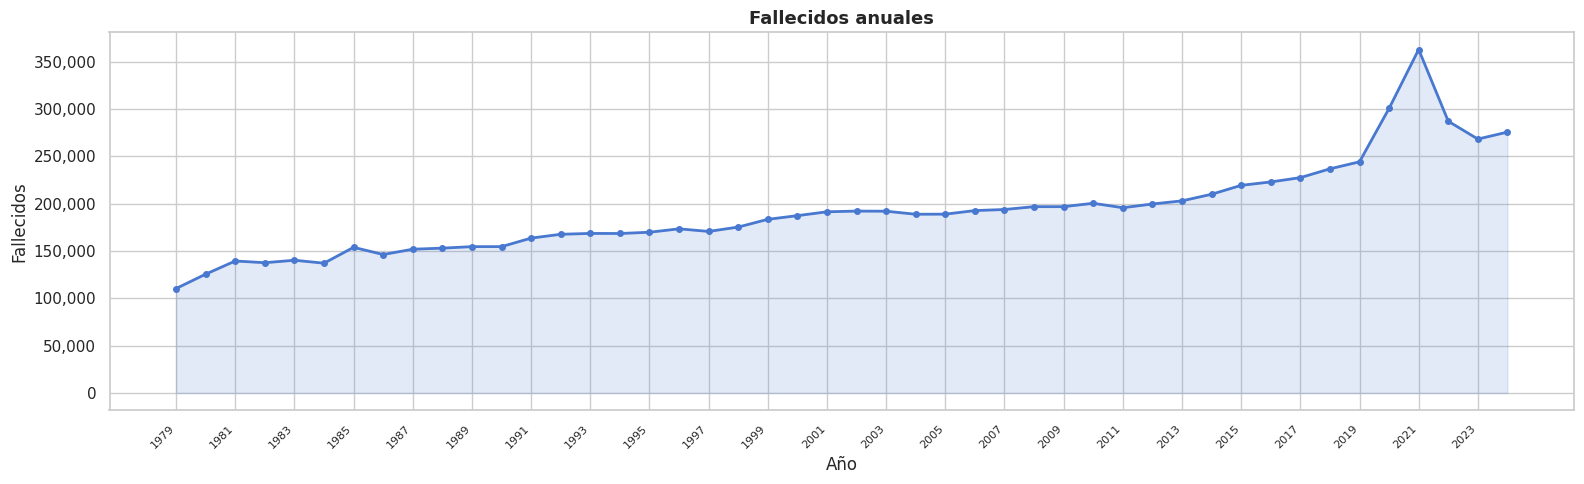

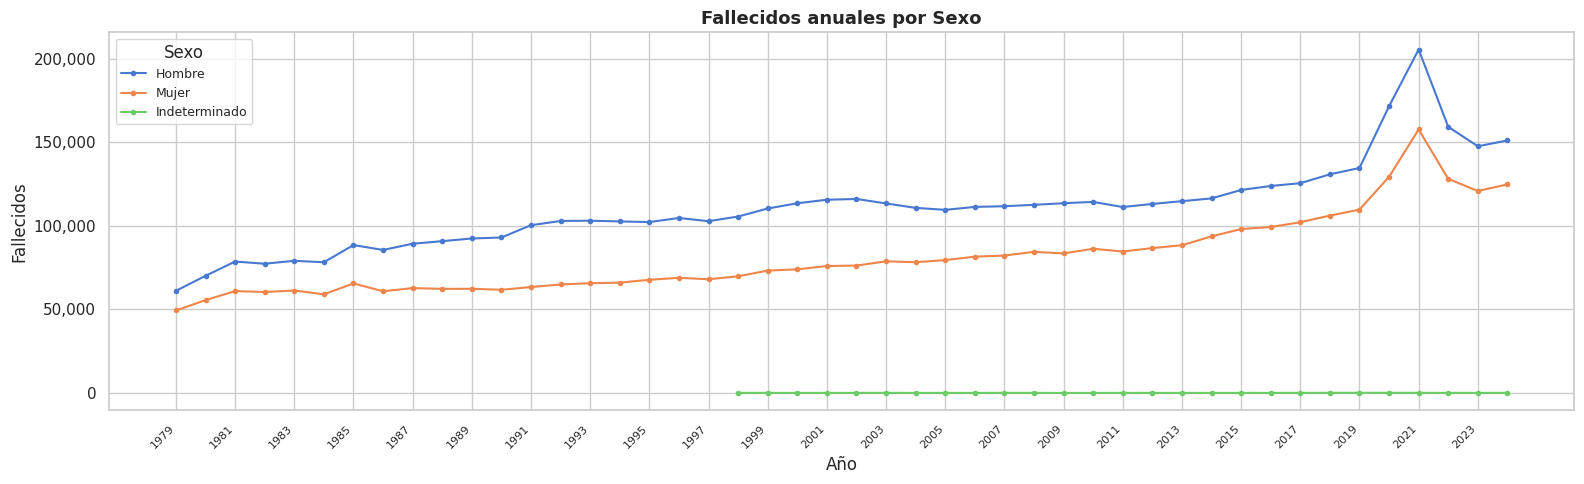

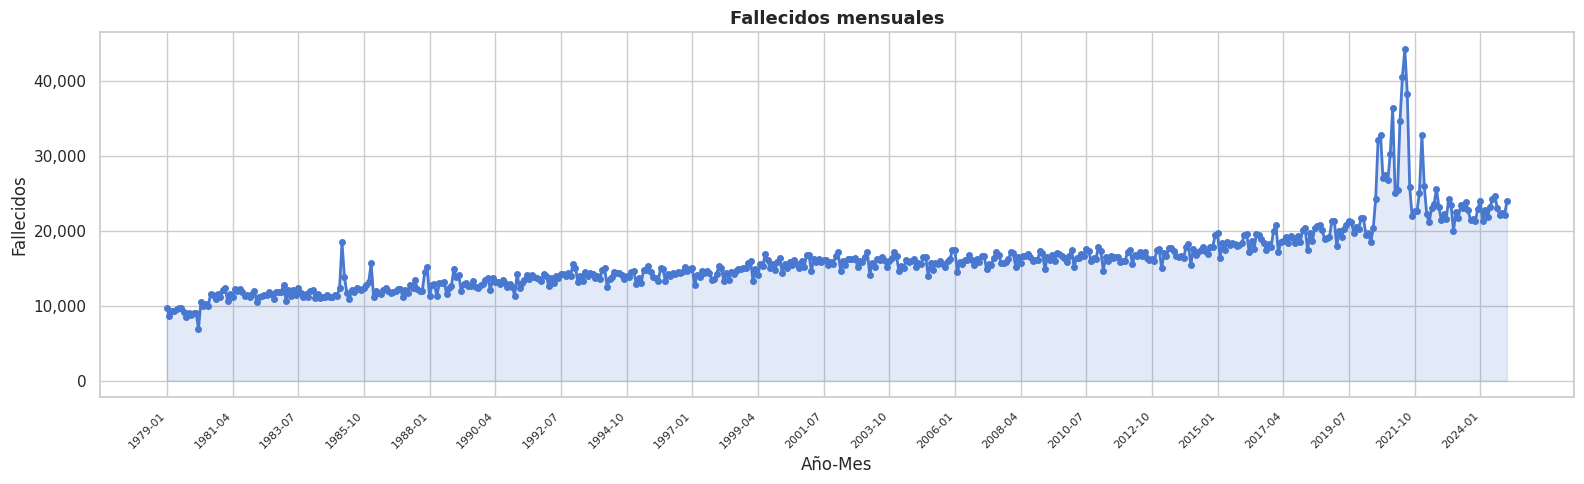

In [13]:
def serie_temporal(
    df: pd.DataFrame,
    col_objetivo: str = COL_OBJETIVO,
    por: str = "anual",
    segmentar_por: str | None = None,
    top_segmentos: int = 5,
) -> pd.DataFrame:
    """
    Grafica la evolución temporal de fallecidos.

    Parámetros
    ----------
    df              : pd.DataFrame   Dataset cargado.
    col_objetivo    : str            Variable objetivo.
    por             : str            'anual' o 'mensual'.
    segmentar_por   : str | None     Campo adicional para descomponer la serie
                                     (ej. 'SEXO'). None = sin segmentación.
    top_segmentos   : int            Si se segmenta, cuántas categorías mostrar.

    Retorna
    -------
    pd.DataFrame con la serie agregada.

    Ejemplos
    --------
    >>> serie_temporal(df, por='anual')
    >>> serie_temporal(df, por='anual', segmentar_por='SEXO')
    >>> serie_temporal(df, por='mensual')
    """
    df_tmp = df.copy()
    df_tmp["AÑO"] = df_tmp["AÑO"].astype(str)
    df_tmp["MES"] = df_tmp["MES"].astype(str).str.zfill(2)

    if por == "anual":
        grupo_time = ["AÑO"]
        eje_x_label = "Año"
    else:
        df_tmp["PERIODO"] = df_tmp["AÑO"] + "-" + df_tmp["MES"]
        grupo_time = ["PERIODO"]
        eje_x_label = "Año-Mes"

    cols_grupo = grupo_time + ([segmentar_por] if segmentar_por else [])
    serie = (
        df_tmp.groupby(cols_grupo, observed=True)[col_objetivo]
              .sum()
              .reset_index()
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    titulo  = f"Fallecidos {'anuales' if por=='anual' else 'mensuales'}"
    if segmentar_por:
        titulo += f" por {ETIQUETAS.get(segmentar_por, segmentar_por)}"
        decoder = DECODIFICADORES.get(segmentar_por, {})
        cats = (
            serie.groupby(segmentar_por, observed=True)[col_objetivo]
                 .sum()
                 .nlargest(top_segmentos)
                 .index.tolist()
        )
        for cat in cats:
            sub = serie[serie[segmentar_por] == cat].sort_values(grupo_time[0])
            etiq = decoder.get(str(cat), str(cat))
            ax.plot(sub[grupo_time[0]].astype(str), sub[col_objetivo],
                    marker="o", markersize=3, linewidth=1.5, label=etiq)
        ax.legend(title=ETIQUETAS.get(segmentar_por, segmentar_por), fontsize=9)
    else:
        serie_plot = serie.sort_values(grupo_time[0])
        ax.plot(serie_plot[grupo_time[0]].astype(str), serie_plot[col_objetivo],
                color="#4878CF", marker="o", markersize=4, linewidth=2)
        ax.fill_between(range(len(serie_plot)), serie_plot[col_objetivo],
                        alpha=0.15, color="#4878CF")

    paso = max(1, len(serie[grupo_time[0]].unique()) // 20)
    ticks = sorted(serie[grupo_time[0]].unique())[::paso]
    ax.set_xticks(range(0, len(serie[grupo_time[0]].unique()), paso))
    ax.set_xticklabels([str(t) for t in ticks], rotation=45, ha="right", fontsize=8)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel(eje_x_label)
    ax.set_ylabel("Fallecidos")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()

    return serie


# ── Serie anual global ────────────────────────────────────────────────────────
serie_anual = serie_temporal(df, por="anual")

# ── Serie anual por sexo ──────────────────────────────────────────────────────
_ = serie_temporal(df, por="anual", segmentar_por="SEXO")

# ── Serie mensual global (todos los años) ────────────────────────────────────
_ = serie_temporal(df, por="mensual")


## 8. ANÁLISIS AUTOMÁTICO DE TODAS LAS VARIABLES


═══════════════════════════════════════════════════════
  DEPARTAMENTO OCURRENCIA  (34 categorías)
═══════════════════════════════════════════════════════
Departamento ocurrencia  Fallecidos  % Total  Media/grupo
                     05     1402973    15.90         1.03
                     11     1374228    15.57         1.03
                     76     1070780    12.13         1.01
                     68      446953     5.06         1.00
                     08      444340     5.03         1.01
                     25      420946     4.77         1.01
                     73      318438     3.61         1.00
                     15      287762     3.26         1.01
                     54      285701     3.24         1.01
                     13      272711     3.09         1.01
                     52      268334     3.04         1.00
                     17      263449     2.99         1.00
                     66      239517     2.71         1.00
                     19      231

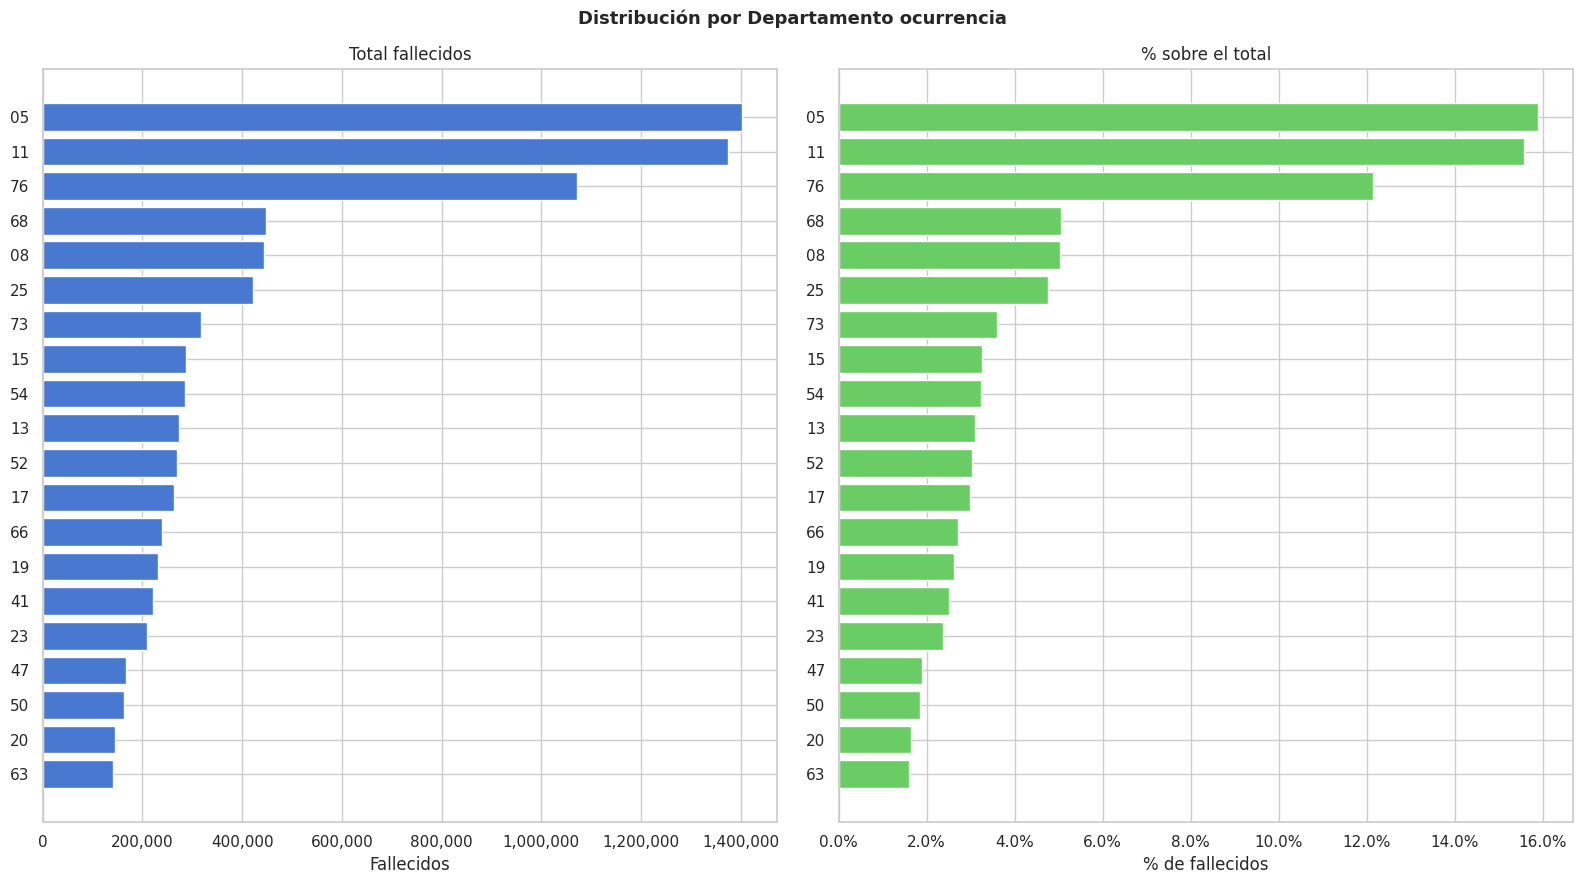


═══════════════════════════════════════════════════════
  ÁREA DEFUNCIÓN  (4 categorías)
═══════════════════════════════════════════════════════
Área defunción  Fallecidos  % Total  Media/grupo
      Cabecera     7614314    86.28         1.01
Centro poblado      654416     7.42         1.01
Rural disperso      533277     6.04         1.01
      Sin info       23024     0.26         1.04


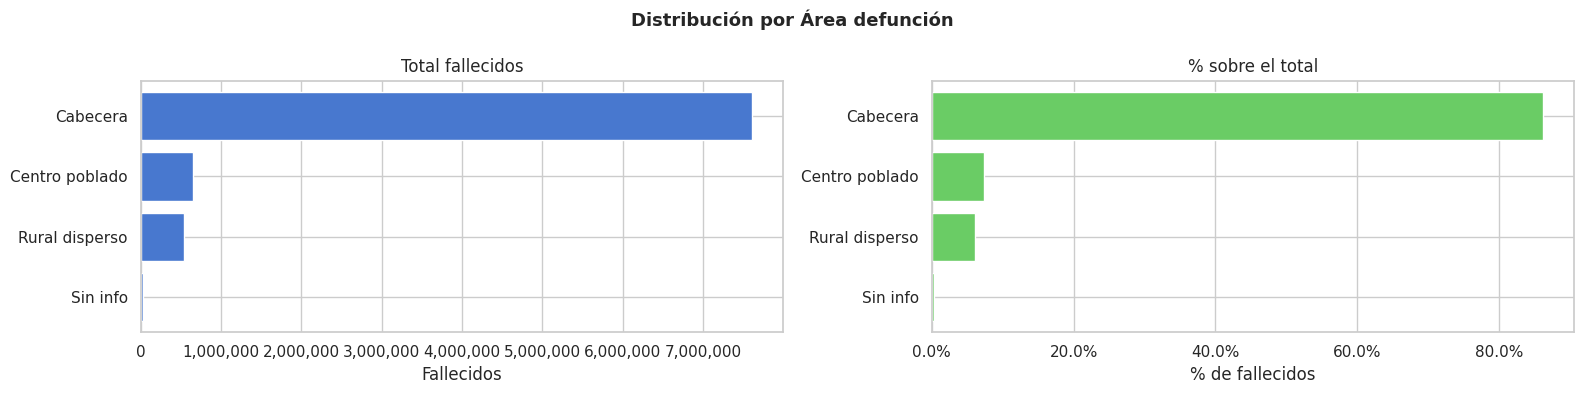


═══════════════════════════════════════════════════════
  AÑO  (46 categorías)
═══════════════════════════════════════════════════════
 Año  Fallecidos  % Total  Media/grupo
2021      363089     4.11         1.00
2020      300853     3.41         1.00
2022      287251     3.25         1.00
2024      275778     3.12         1.00
2023      268411     3.04         1.00
2019      244355     2.77         1.00
2018      236932     2.68         1.00
2017      227624     2.58         1.00
2016      223078     2.53         1.00
2015      219472     2.49         1.00
2014      210051     2.38         1.00
2013      203071     2.30         1.00
2010      200524     2.27         1.00
2012      199756     2.26         1.00
2008      196943     2.23         1.00
2009      196933     2.23         1.00
2011      195823     2.22         1.00
2007      193936     2.20         1.00
2006      192814     2.18         1.00
2002      192262     2.18         1.00


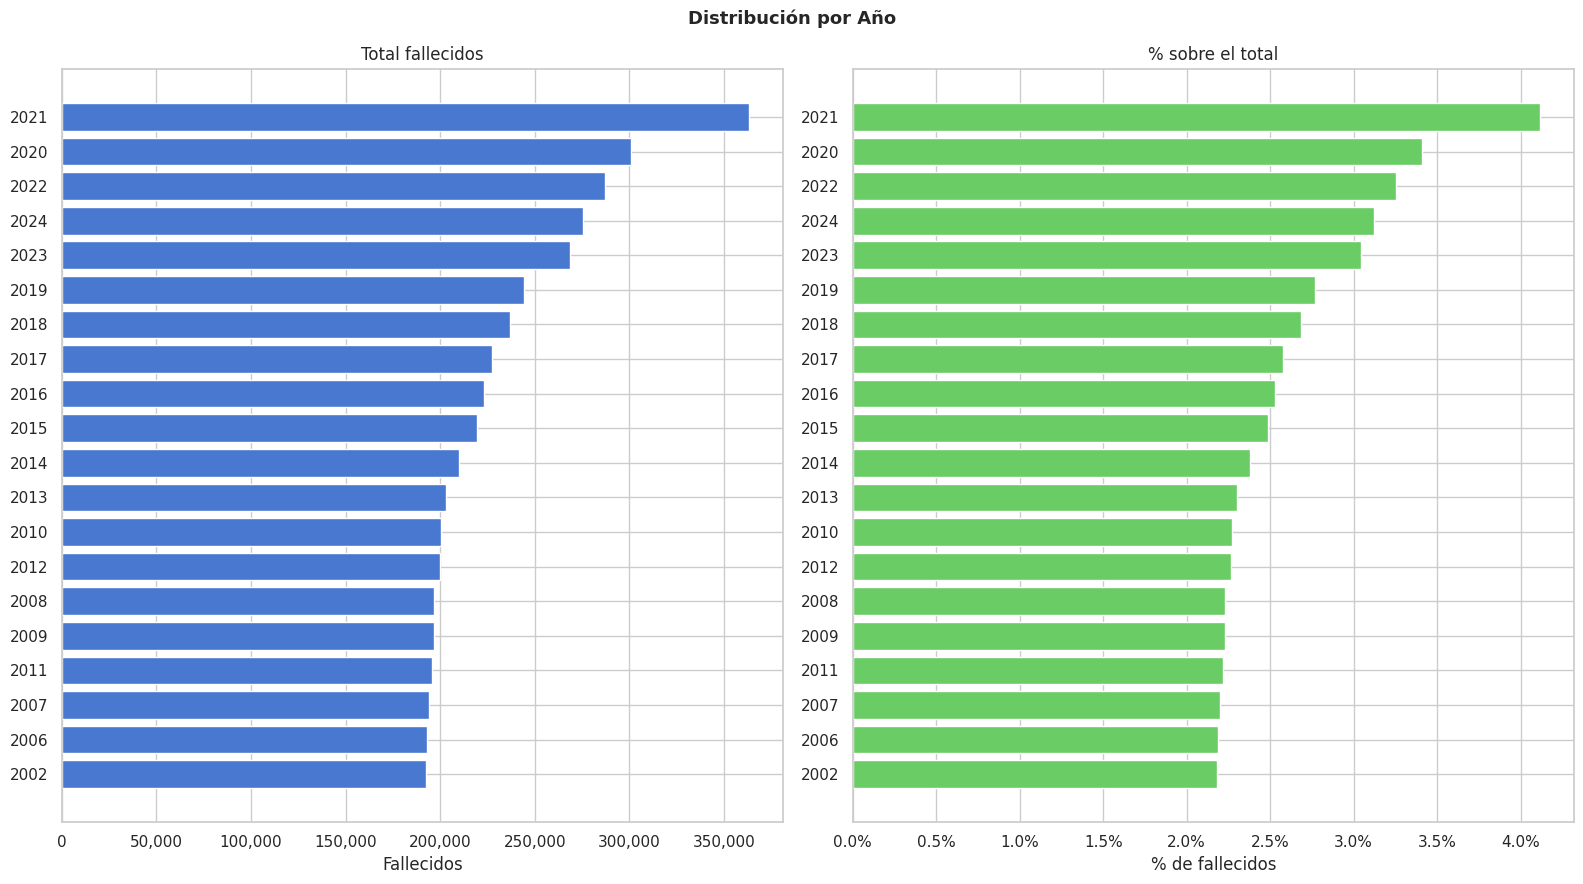


═══════════════════════════════════════════════════════
  MES  (12 categorías)
═══════════════════════════════════════════════════════
Mes  Fallecidos  % Total  Media/grupo
 01      784896     8.89         1.02
 07      775714     8.79         1.02
 12      772697     8.76         1.02
 06      752420     8.53         1.01
 05      750167     8.50         1.01
 08      741799     8.41         1.01
 10      725673     8.22         1.01
 11      722544     8.19         1.02
 03      718971     8.15         1.01
 09      707445     8.02         1.01
 04      704771     7.99         1.01
 02      667934     7.57         1.01


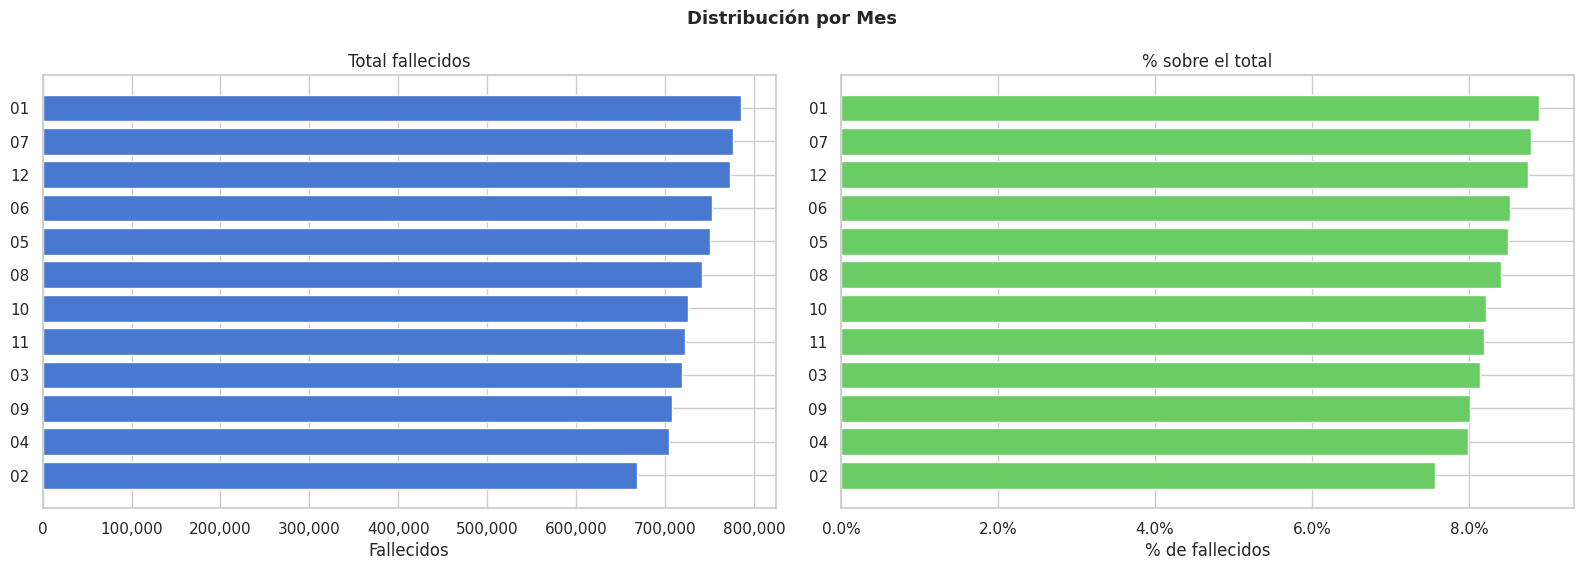


═══════════════════════════════════════════════════════
  SEXO  (3 categorías)
═══════════════════════════════════════════════════════
         Sexo  Fallecidos  % Total  Media/grupo
       Hombre     5085707    57.63         1.02
        Mujer     3738168    42.36         1.01
Indeterminado        1156     0.01         1.03


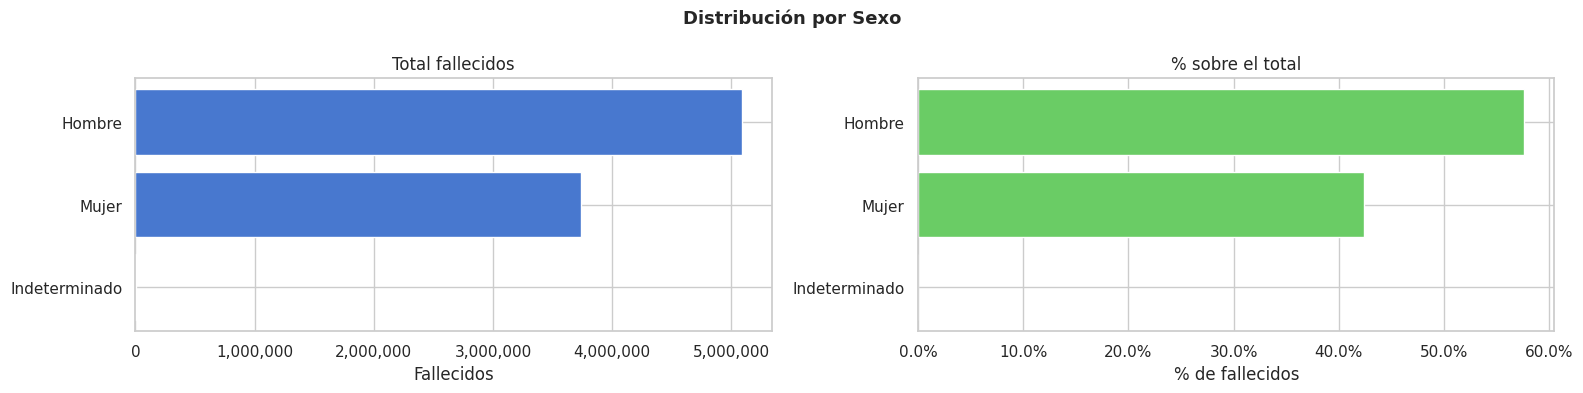


═══════════════════════════════════════════════════════
  GRUPO DE EDAD  (30 categorías)
═══════════════════════════════════════════════════════
Grupo de edad  Fallecidos  % Total  Media/grupo
           24      901135    10.21         1.01
           23      841239     9.53         1.01
           22      800554     9.07         1.01
           21      708683     8.03         1.01
           25      704172     7.98         1.00
           20      598149     6.78         1.01
           19      491810     5.57         1.01
           18      389511     4.41         1.01
           17      322089     3.65         1.01
           12      318075     3.60         1.05
           26      301574     3.42         1.00
           13      295565     3.35         1.03
           16      277656     3.15         1.01
           14      274960     3.12         1.02
           15      262061     2.97         1.01
           11      260784     2.96         1.08
           10      126798     1.44    

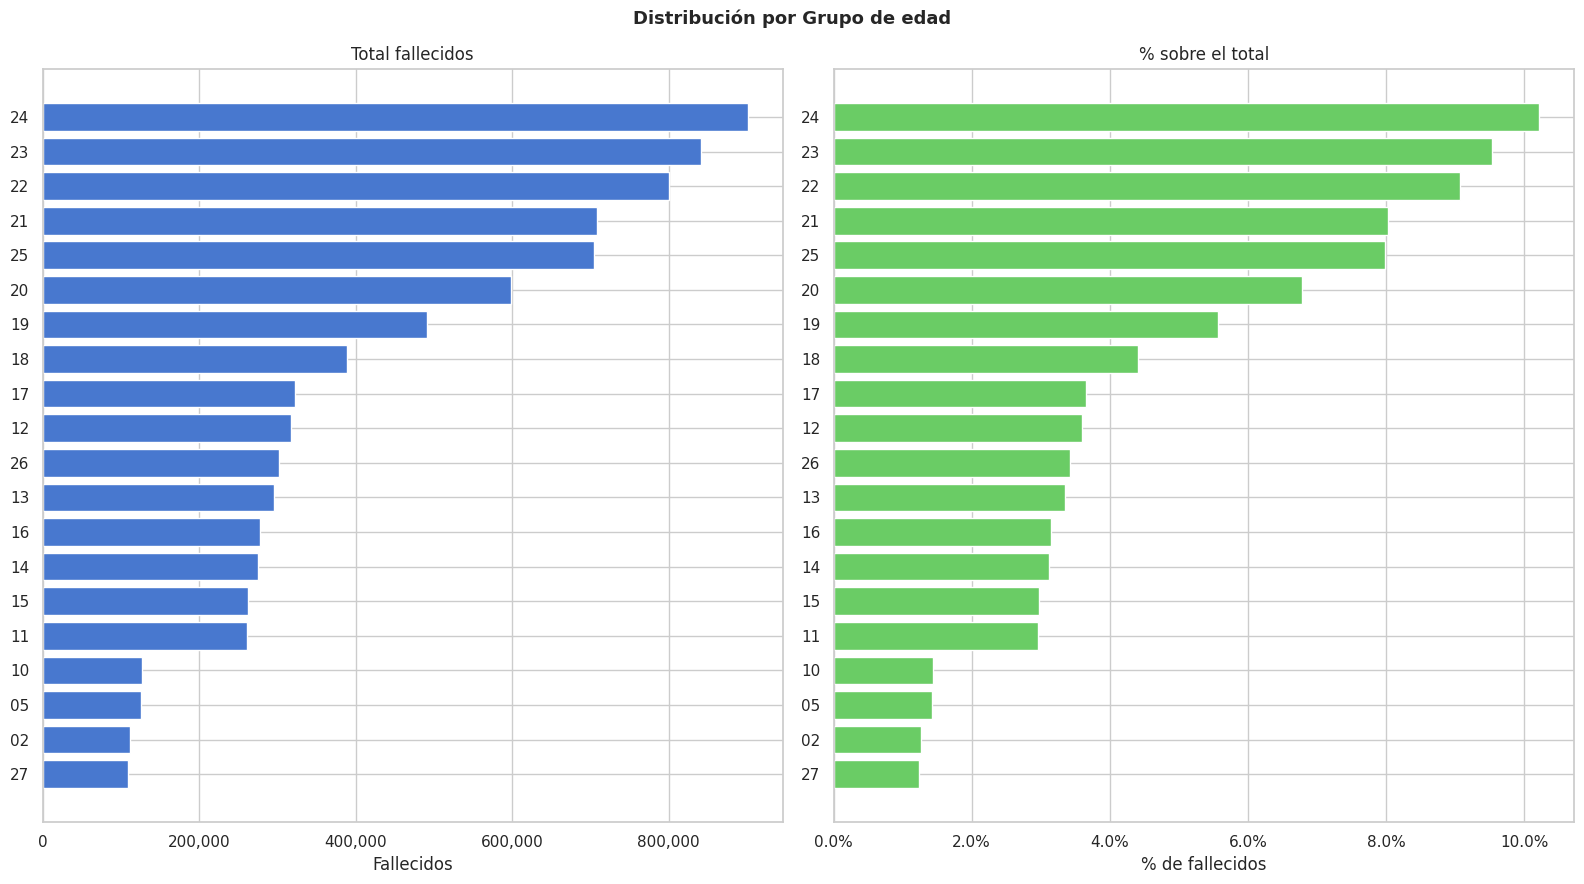


═══════════════════════════════════════════════════════
  ESTADO CIVIL  (8 categorías)
═══════════════════════════════════════════════════════
         Estado civil  Fallecidos  % Total  Media/grupo
            Soltero/a     2226965    25.23         1.03
             Casado/a     1552907    17.60         1.02
           Separado/a     1183314    13.41         1.00
          Unión libre     1153675    13.07         1.01
No aplica (< 10 años)      975934    11.06         1.00
              Viudo/a      927787    10.51         1.01
             Sin info      804448     9.12         1.00
             Sin info           1     0.00         1.00


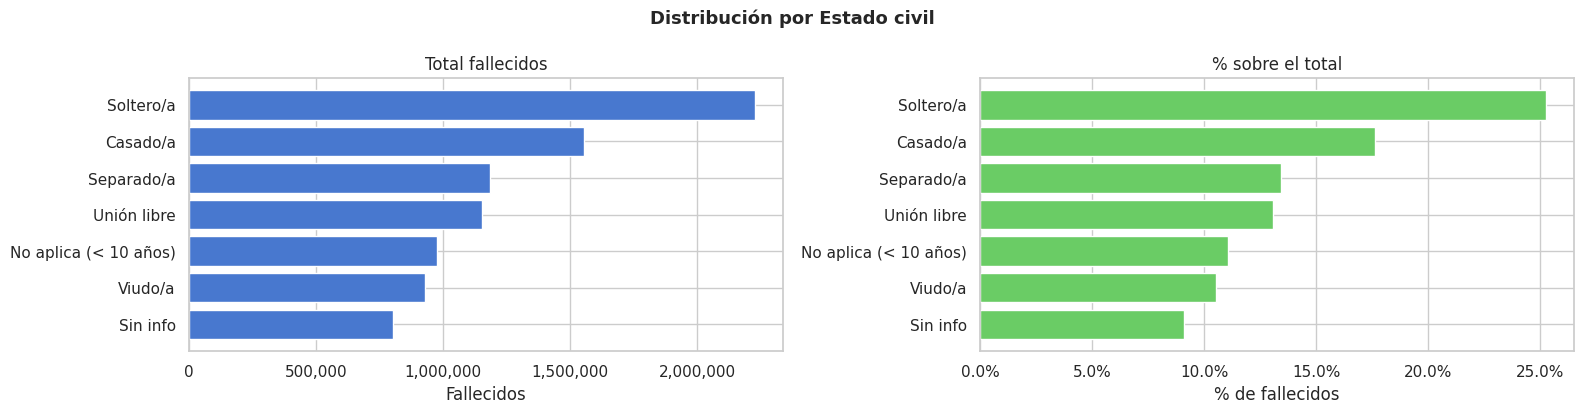


═══════════════════════════════════════════════════════
  DEPARTAMENTO RESIDENCIA  (37 categorías)
═══════════════════════════════════════════════════════
Departamento residencia  Fallecidos  % Total  Media/grupo
                     05     1368016    15.50         1.03
                     11     1217483    13.80         1.03
                     76     1040859    11.79         1.01
                     25      483343     5.48         1.00
                     68      431600     4.89         1.00
                     08      410643     4.65         1.01
                     73      328488     3.72         1.00
                     15      300420     3.40         1.01
                     54      281137     3.19         1.01
                     13      275023     3.12         1.01
                     52      263122     2.98         1.00
                     17      259866     2.94         1.00
                     19      249328     2.83         1.01
                     66      227

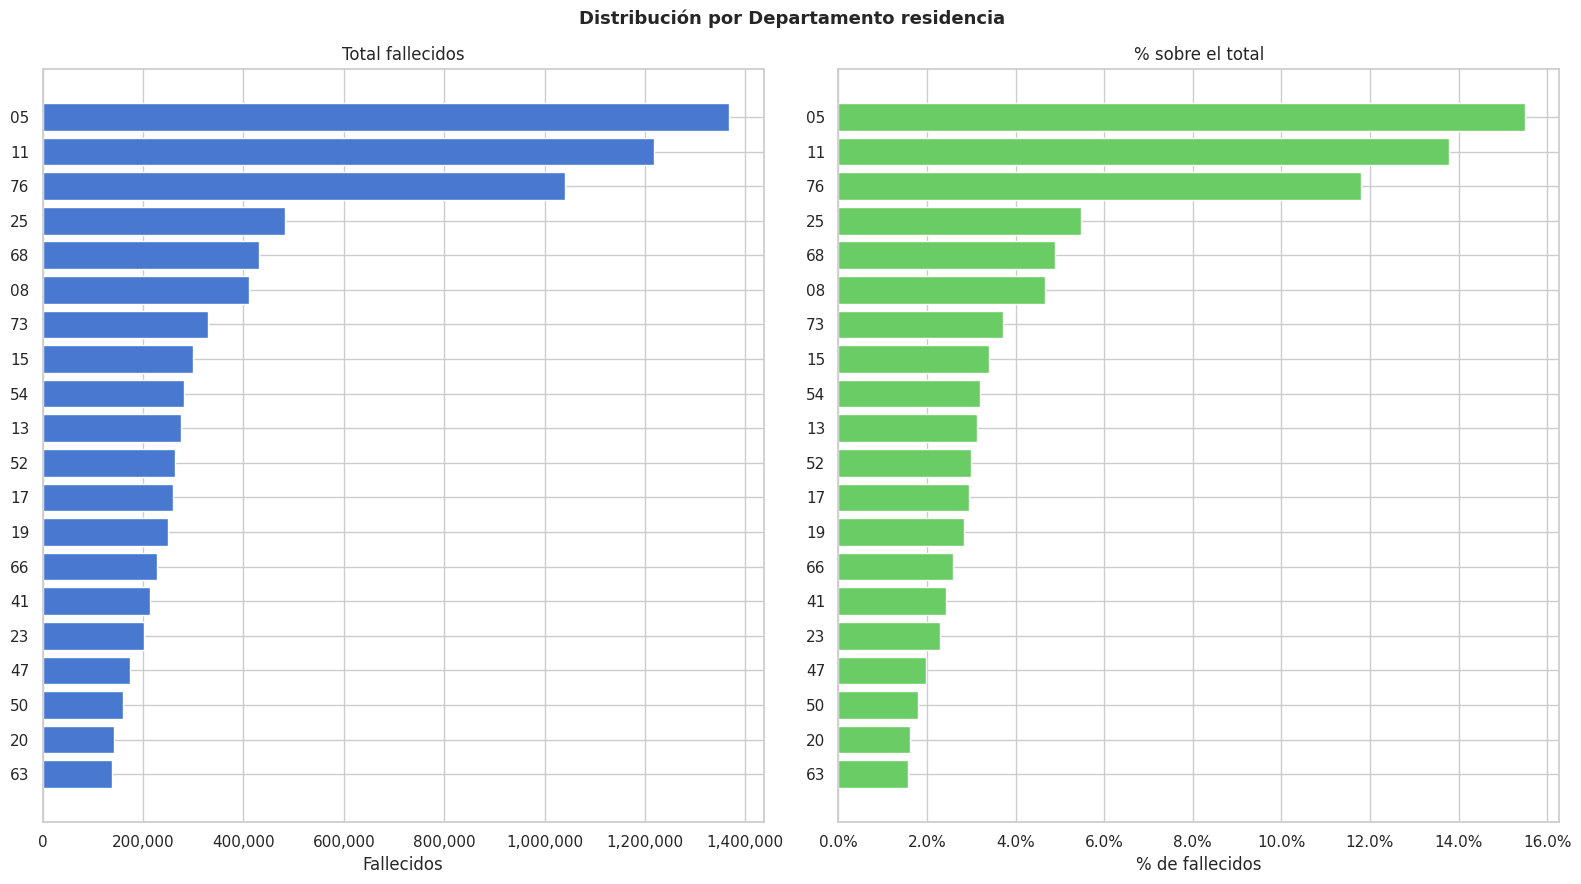


═══════════════════════════════════════════════════════
  SITIO DE DEFUNCIÓN  (7 categorías)
═══════════════════════════════════════════════════════
Sitio de defunción  Fallecidos  % Total  Media/grupo
  Hospital/clínica     4563595    51.71         1.01
       Vía pública     2069374    23.45         1.01
              Casa     1330220    15.07         1.03
         Bienestar      387193     4.39         1.01
   Centro de salud      228347     2.59         1.08
              Otro      190034     2.15         1.00
          Sin info       56268     0.64         1.02


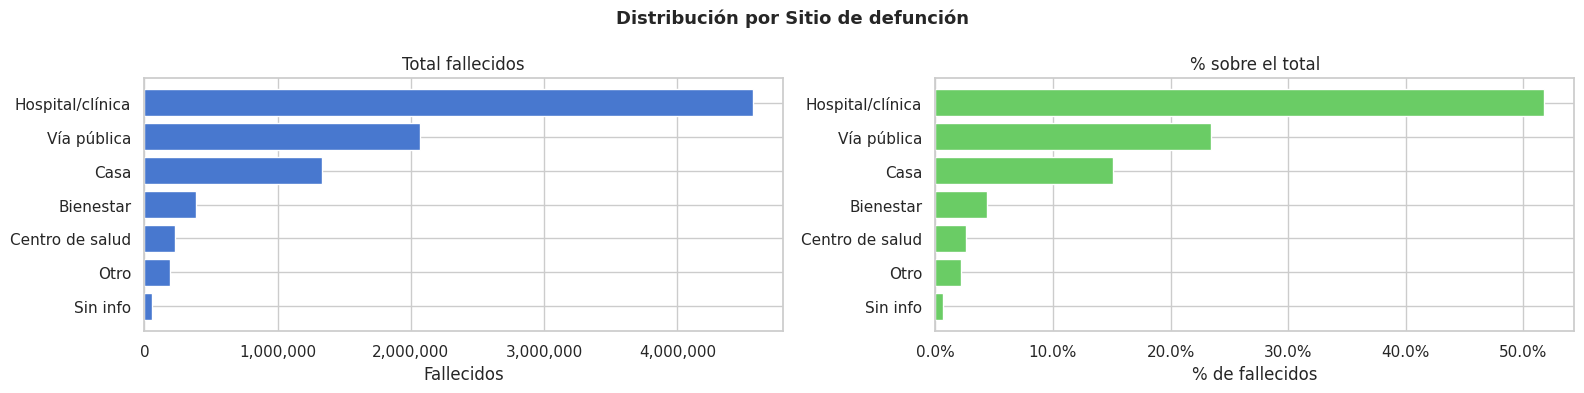


═══════════════════════════════════════════════════════
  TIPO CERTIFICACIÓN MÉDICA  (6 categorías)
═══════════════════════════════════════════════════════
Tipo certificación médica  Fallecidos  % Total  Media/grupo
       Médico no tratante     4507600    51.08         1.02
          Médico tratante     2887856    32.72         1.01
           Médico legista     1389386    15.74         1.01
              Otro médico       28099     0.32         1.00
                 Sin info        6872     0.08         1.08
           Sin asistencia        5218     0.06         1.08


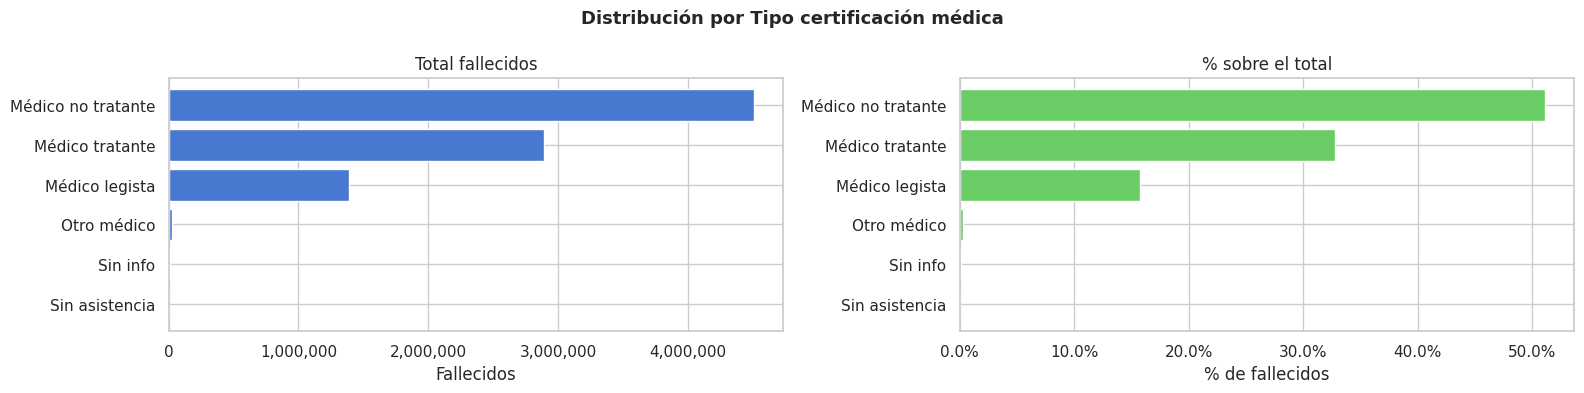


═══════════════════════════════════════════════════════
  CAUSA BÁSICA LISTA 105  (105 categorías)
═══════════════════════════════════════════════════════
Causa básica lista 105  Fallecidos  % Total  Media/grupo
                   051     1165848    13.21         1.01
                   101      832995     9.44         1.07
                   055      590459     6.69         1.01
                   089      415249     4.71         1.01
                   060      407185     4.61         1.00
                   059      290065     3.29         1.02
                   050      282148     3.20         1.01
                   090      279186     3.16         1.01
                   041      260652     2.95         1.00
                   013      195192     2.21         1.01
                   054      179067     2.03         1.01
                   010      173571     1.97         1.00
                   020      142510     1.61         1.00
                   053      127887     1.45   

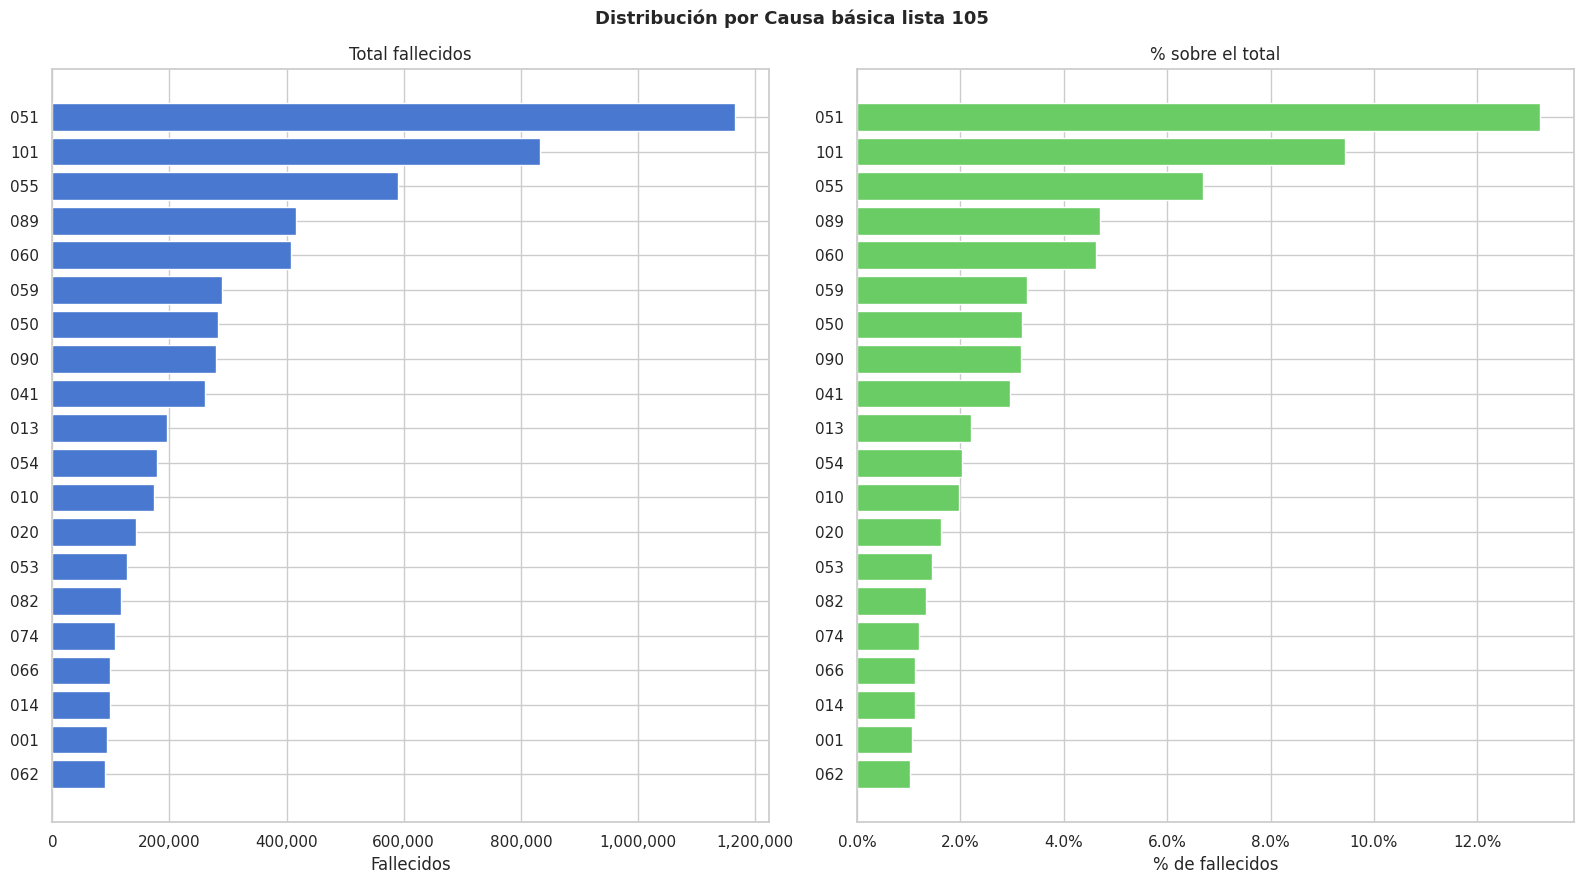


✅ Análisis completado para 11 variables.


In [14]:
def analisis_todas_variables(
    df: pd.DataFrame,
    col_objetivo: str = COL_OBJETIVO,
    top_n: int = 20,
    excluir: list[str] | None = None,
    solo_graficar: list[str] | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Ejecuta distribucion_por_variable() para todas las variables del dataset.

    Parámetros
    ----------
    df            : pd.DataFrame       Dataset cargado.
    col_objetivo  : str                Variable objetivo (se excluye del loop).
    top_n         : int                Máximo de categorías por gráfico.
    excluir       : list[str] | None   Columnas a omitir además de col_objetivo.
    solo_graficar : list[str] | None   Si se indica, solo procesa esas columnas.

    Retorna
    -------
    dict[str, pd.DataFrame]
        Diccionario {nombre_columna: tabla_distribución}.

    Ejemplo
    -------
    >>> resultados = analisis_todas_variables(df, excluir=['CÓDIGO MUNICIPIO'])
    >>> resultados['SEXO']
    """
    excluir  = excluir or []
    excluir += [col_objetivo]

    columnas = (
        solo_graficar
        if solo_graficar
        else [c for c in df.columns if c not in excluir]
    )

    resultados = {}
    for col in columnas:
        try:
            tabla = distribucion_por_variable(
                df, col, col_objetivo=col_objetivo,
                top_n=top_n, graficar=True,
            )
            resultados[col] = tabla
        except Exception as e:
            print(f"  [ERROR] {col}: {e}")

    print(f"\n✅ Análisis completado para {len(resultados)} variables.")
    return resultados


# ── Correr para todas las variables (excluimos municipios por alta cardinalidad)
resultados = analisis_todas_variables(
    df,
    excluir=["CÓDIGO MUNICIPIO", "CÓDIGO MUNICIPIO RESIDENCIA",
             "CÓDIGO CAUSA BÁSICA DEFUNCIÓN"],   # Alta cardinalidad: ver sección 9
)


## 9. VARIABLES DE ALTA CARDINALIDAD


Causa básica lista 105 — Top 20 por fallecidos
  Universo total: 105 categorías | 8,825,031 fallecidos
  Top 20 concentra: 67.4% de los fallecidos



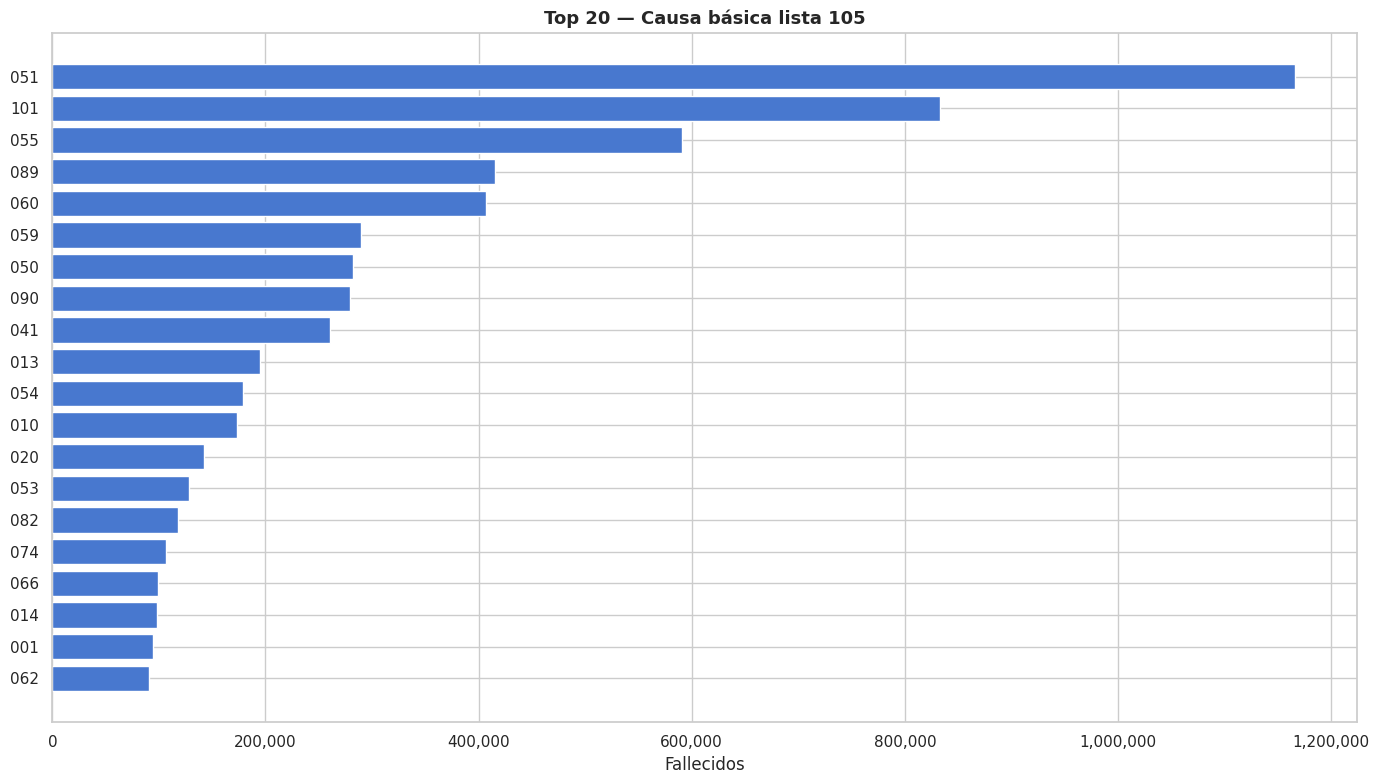


Causa básica (CIE) — Top 20 por fallecidos
  Universo total: 10422 categorías | 8,825,031 fallecidos
  Top 20 concentra: 33.2% de los fallecidos



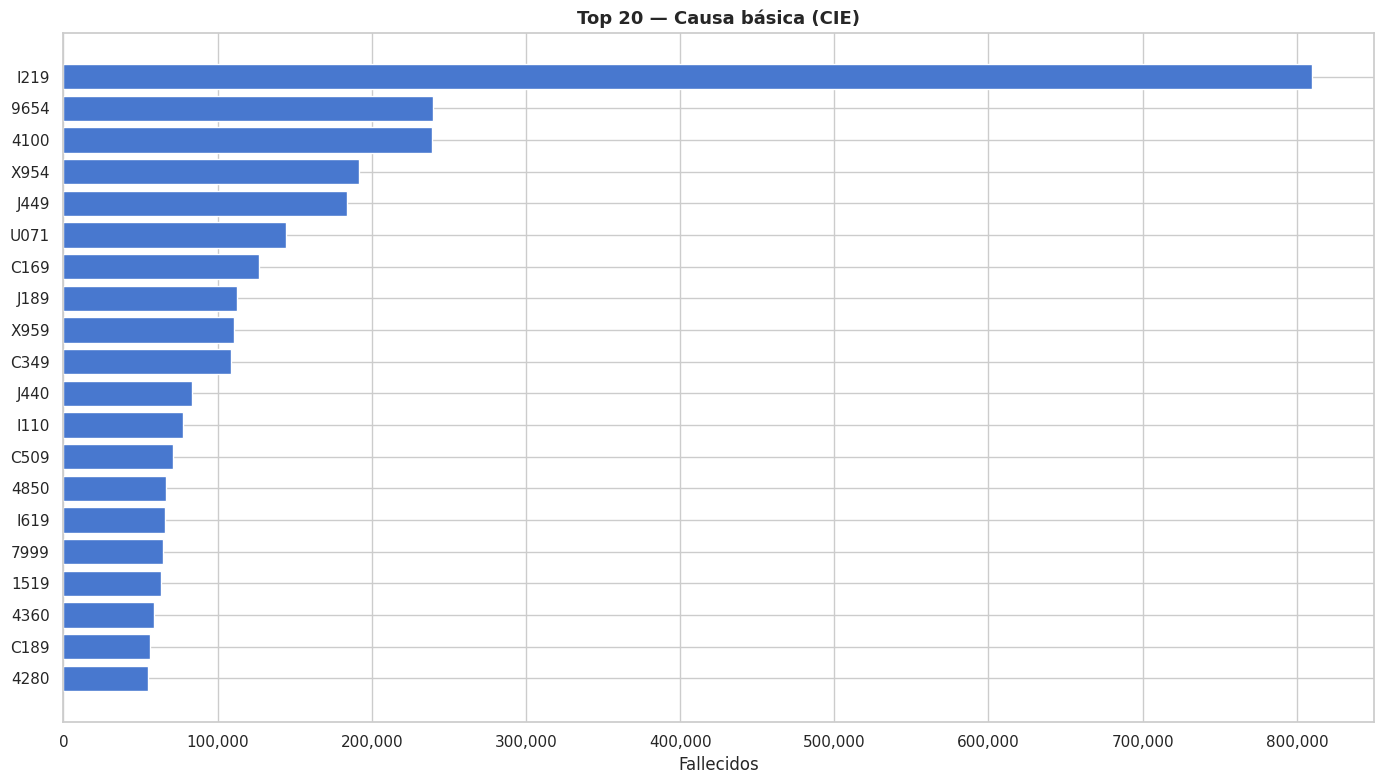


Municipio ocurrencia — Top 20 por fallecidos
  Universo total: 592 categorías | 8,825,031 fallecidos
  Top 20 concentra: 67.9% de los fallecidos



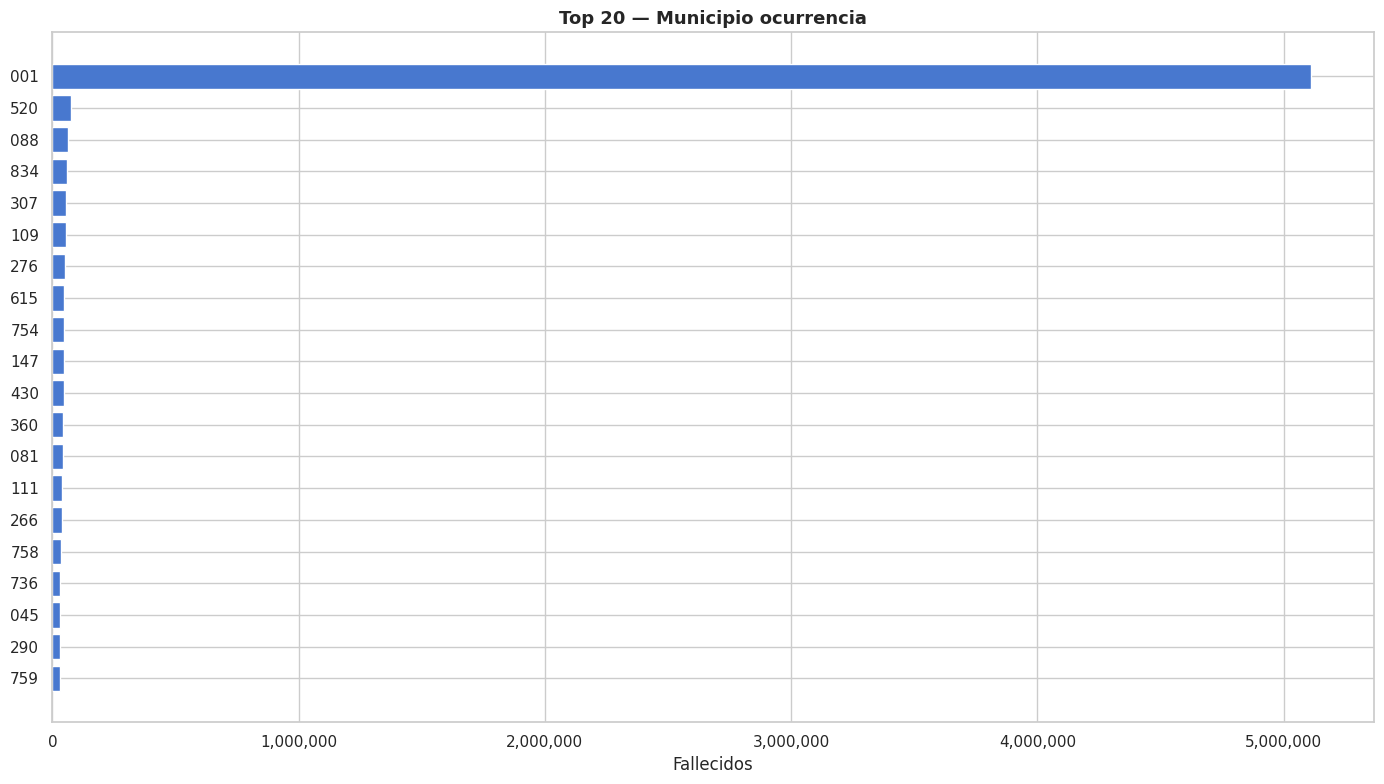

In [15]:
def top_categorias(
    df: pd.DataFrame,
    columna: str,
    col_objetivo: str = COL_OBJETIVO,
    top_n: int = 20,
) -> pd.DataFrame:
    """
    Para variables de alta cardinalidad (municipios, causas CIE), muestra solo
    el Top N con mayor peso en fallecidos, incluyendo la concentración acumulada.

    Parámetros
    ----------
    df           : pd.DataFrame
    columna      : str            Variable de alta cardinalidad.
    col_objetivo : str            Variable objetivo.
    top_n        : int            Cuántas categorías mostrar.

    Retorna
    -------
    pd.DataFrame con el ranking de las top_n categorías.

    Ejemplo
    -------
    >>> top_categorias(df, 'CÓDIGO CAUSA BÁSICA DEFUNCIÓN', top_n=20)
    """
    etiqueta = ETIQUETAS.get(columna, columna)
    total    = df[col_objetivo].sum()

    tabla = (
        df.groupby(columna, observed=True)[col_objetivo]
          .sum()
          .reset_index()
          .sort_values(col_objetivo, ascending=False)
          .head(top_n)
    )
    tabla["% del total"]   = (tabla[col_objetivo] / total * 100).round(2)
    tabla["% acumulado"]   = tabla["% del total"].cumsum().round(2)

    print(f"\n{etiqueta} — Top {top_n} por fallecidos")
    print(f"  Universo total: {df[columna].nunique()} categorías | {total:,} fallecidos")
    print(f"  Top {top_n} concentra: {tabla['% del total'].sum():.1f}% de los fallecidos")
    print()

    fig, ax = plt.subplots(figsize=(14, max(5, top_n * 0.4)))
    ax.barh(tabla[columna].astype(str)[::-1],
            tabla[col_objetivo][::-1],
            color="#4878CF", edgecolor="white")
    ax.set_title(f"Top {top_n} — {etiqueta}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Fallecidos")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()

    return tabla


_ = top_categorias(df, "CÓDIGO CAUSA BÁSICA LISTA 105",  top_n=20)
_ = top_categorias(df, "CÓDIGO CAUSA BÁSICA DEFUNCIÓN",  top_n=20)
_ = top_categorias(df, "CÓDIGO MUNICIPIO",               top_n=20)


## 10. CORRELACIÓN ENTRE VARIABLES Y LA VARIABLE OBJETIVO

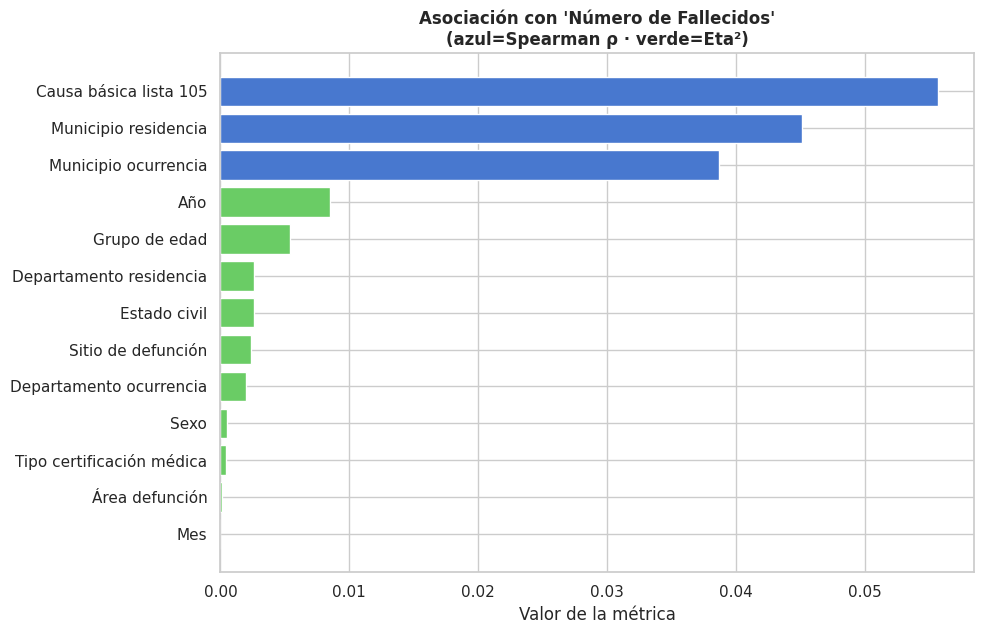

                      Variable                  Etiqueta       Métrica  Valor
 CÓDIGO CAUSA BÁSICA LISTA 105    Causa básica lista 105    Spearman ρ   0.06
   CÓDIGO MUNICIPIO RESIDENCIA      Municipio residencia    Spearman ρ   0.05
              CÓDIGO MUNICIPIO      Municipio ocurrencia    Spearman ρ   0.04
                           AÑO                       Año Eta² (categ.)   0.01
           AGRUPACIÓN EDADES 1             Grupo de edad Eta² (categ.)   0.01
CÓDIGO DEPARTAMENTO RESIDENCIA   Departamento residencia Eta² (categ.)   0.00
                  ESTADO CIVIL              Estado civil Eta² (categ.)   0.00
        CÓDIGO SITIO DEFUNCIÓN        Sitio de defunción Eta² (categ.)   0.00
           CÓDIGO DEPARTAMENTO   Departamento ocurrencia Eta² (categ.)   0.00
                          SEXO                      Sexo Eta² (categ.)   0.00
   CÓDIGO CERTIFICACIÓN MÉDICA Tipo certificación médica Eta² (categ.)   0.00
                ÁREA DEFUNCIÓN            Área defunción Eta² (c

In [16]:
def correlacion_con_objetivo(
    df: pd.DataFrame,
    col_objetivo: str = COL_OBJETIVO,
    top_n: int = 15,
) -> pd.DataFrame:
    """
    Calcula la correlación de Spearman entre la variable objetivo y cada
    variable numérica o codificada. Para variables categóricas se usa
    el eta-cuadrado (varianza explicada por la categoría).

    Parámetros
    ----------
    df           : pd.DataFrame
    col_objetivo : str            Variable objetivo.
    top_n        : int            Cuántas variables mostrar en el gráfico.

    Retorna
    -------
    pd.DataFrame con columnas: Variable, Etiqueta, Métrica, Valor.

    Notas
    -----
    - Variables con cardinalidad ≤ 50 → eta-cuadrado (asociación no lineal).
    - Variables numéricas → Spearman (monótona, robusta a outliers).
    - Se excluyen variables con cardinalidad > 1000 (municipios, CIE).
    """
    from scipy import stats as sp_stats

    resultados = []
    total_var  = df[col_objetivo].var()

    for col in df.columns:
        if col == col_objetivo:
            continue
        n_unicos = df[col].nunique()
        if n_unicos > 1000:
            continue   # Demasiada cardinalidad
        try:
            if df[col].dtype.name == "category" and n_unicos <= 50:
                # Eta-cuadrado: varianza inter-grupos / varianza total
                grupos   = [g[col_objetivo].values
                            for _, g in df.groupby(col, observed=True)]
                ss_entre = sum(len(g) * (g.mean() - df[col_objetivo].mean())**2
                               for g in grupos)
                eta2     = ss_entre / (total_var * len(df))
                resultados.append({
                    "Variable": col,
                    "Etiqueta": ETIQUETAS.get(col, col),
                    "Métrica" : "Eta² (categ.)",
                    "Valor"   : round(eta2, 4),
                })
            else:
                # Spearman sobre códigos numéricos
                x = pd.to_numeric(df[col].astype(str), errors="coerce")
                mask = x.notna()
                rho, _ = sp_stats.spearmanr(x[mask], df.loc[mask, col_objetivo])
                resultados.append({
                    "Variable": col,
                    "Etiqueta": ETIQUETAS.get(col, col),
                    "Métrica" : "Spearman ρ",
                    "Valor"   : round(abs(rho), 4),
                })
        except Exception:
            continue

    tabla = (pd.DataFrame(resultados)
               .sort_values("Valor", ascending=False)
               .reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(10, max(4, len(tabla.head(top_n)) * 0.5)))
    colores = ["#4878CF" if m == "Spearman ρ" else "#6ACC65"
               for m in tabla.head(top_n)["Métrica"]]
    ax.barh(tabla.head(top_n)["Etiqueta"][::-1],
            tabla.head(top_n)["Valor"][::-1],
            color=colores[::-1], edgecolor="white")
    ax.set_title(f"Asociación con '{col_objetivo}'\n(azul=Spearman ρ · verde=Eta²)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor de la métrica")
    plt.tight_layout()
    plt.show()

    print(tabla.head(top_n).to_string(index=False))
    return tabla


tabla_corr = correlacion_con_objetivo(df)
